In [ ]:
 # Do African American men have a higher rate of hospital stays exceeding 10 days compared to Caucasian men?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Import Data File
df = pd.read_csv("https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv")

In [ ]:
# to see the data and column names

In [3]:
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [ ]:
# to check for missing data

In [4]:
df.isnull().any()

encounter_id                False
patient_nbr                 False
race                        False
gender                      False
age                         False
weight                      False
admission_type_id           False
discharge_disposition_id    False
admission_source_id         False
time_in_hospital            False
payer_code                  False
medical_specialty           False
num_lab_procedures          False
num_procedures              False
num_medications             False
number_outpatient           False
number_emergency            False
number_inpatient            False
diag_1                      False
diag_2                      False
diag_3                      False
number_diagnoses            False
max_glu_serum                True
A1Cresult                    True
metformin                   False
repaglinide                 False
nateglinide                 False
chlorpropamide              False
glimepiride                 False
acetohexamide 

In [2]:
df_subset = df[['patient_nbr', 'race', 'gender', 'admission_type_id','time_in_hospital']]

In [ ]:
# remove? from data set in col race

In [3]:
df_subsetClean = df_subset[df_subset['race'] != '?']

In [14]:
df_subsetClean.head(20)

,patient_nbr,race,gender,admission_type_id,time_in_hospital
0,8222157,Caucasian,Female,6,1
1,55629189,Caucasian,Female,1,3
2,86047875,AfricanAmerican,Female,1,2
3,82442376,Caucasian,Male,1,2
4,42519267,Caucasian,Male,1,1
5,82637451,Caucasian,Male,2,3
6,84259809,Caucasian,Male,3,4
7,114882984,Caucasian,Male,1,5
8,48330783,Caucasian,Female,2,13
9,63555939,Caucasian,Female,3,12


In [ ]:
# create DF with only Males

In [4]:
df_genderMale = df_subsetClean[df_subsetClean['gender'] == 'Male']

In [16]:
df_genderMale.head(10)

,patient_nbr,race,gender,admission_type_id,time_in_hospital
3,82442376,Caucasian,Male,1,2
4,42519267,Caucasian,Male,1,1
5,82637451,Caucasian,Male,2,3
6,84259809,Caucasian,Male,3,4
7,114882984,Caucasian,Male,1,5
11,77391171,AfricanAmerican,Male,2,7
13,77586282,Caucasian,Male,1,10
15,86328819,AfricanAmerican,Male,1,12
16,92519352,AfricanAmerican,Male,1,4
18,107389323,AfricanAmerican,Male,1,5


In [ ]:
# to sort and filter data by race and stays longer than or equal to 10 days

In [34]:
df_Caus= df_genderMale[(df_genderMale['race'] == 'Caucasian') & (df_genderMale['time_in_hospital'] >=10)].sort_values(by='time_in_hospital', ascending=True) 

In [35]:
df_Caus.head(10)

,patient_nbr,race,gender,admission_type_id,time_in_hospital
13,77586282,Caucasian,Male,1,10
39654,42607161,Caucasian,Male,1,10
39621,24461352,Caucasian,Male,1,10
18236,63125073,Caucasian,Male,6,10
18294,19107558,Caucasian,Male,2,10
39449,24969186,Caucasian,Male,2,10
81843,103736943,Caucasian,Male,3,10
18418,3337488,Caucasian,Male,1,10
39446,42957558,Caucasian,Male,1,10
81533,85443048,Caucasian,Male,1,10


In [36]:
df_AfricanA= df_genderMale[(df_genderMale['race'] == 'AfricanAmerican') & (df_genderMale['time_in_hospital'] >=10)].sort_values(by='time_in_hospital', ascending=True)

In [37]:
df_AfricanA.head(10)

,patient_nbr,race,gender,admission_type_id,time_in_hospital
34944,23230467,AfricanAmerican,Male,1,10
54838,61934121,AfricanAmerican,Male,2,10
31750,6676533,AfricanAmerican,Male,2,10
16212,2681658,AfricanAmerican,Male,1,10
16489,1692423,AfricanAmerican,Male,1,10
68212,60243183,AfricanAmerican,Male,1,10
55059,88410879,AfricanAmerican,Male,1,10
31088,24280542,AfricanAmerican,Male,1,10
17073,1070271,AfricanAmerican,Male,3,10
66977,25464258,AfricanAmerican,Male,1,10


In [42]:
count_Caus = len(df_Caus)
count_AfricanA = len(df_AfricanA)

In [43]:
groups = ['Caucasian', 'African American']
counts = [count_Caus , count_AfricanA]

<BarContainer object of 2 artists>

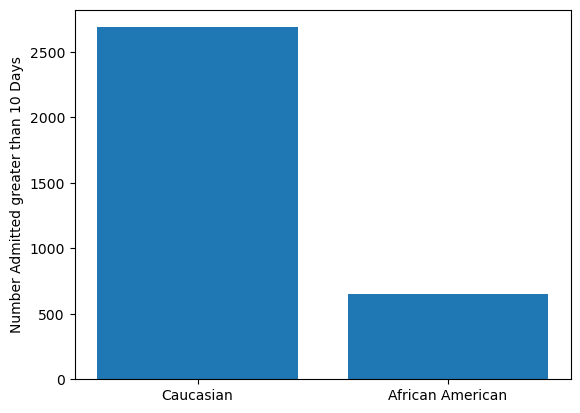

In [47]:
plt.ylabel('Number Admitted greater than 10 Days')
plt.bar(groups, counts)

In [ ]:
#Although commonly assumed otherwise, data show that more Caucasian men experience hospital stays of 10 days or longer compared to African American men—approximately
#2,700 versus 680.